In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
os.getcwd()

'/content'

In [7]:
df=pd.read_csv("dirty_cafe_sales.csv")

In [8]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [9]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [11]:
df.shape

(10000, 8)

In [12]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [13]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [14]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [15]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


In [16]:
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [17]:
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')

In [18]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,float64
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


In [19]:
mn=df['Quantity'].mean().round()

In [20]:
df['Quantity']=df['Quantity'].fillna(mn)

In [21]:
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,0
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [22]:
df['Price Per Unit']=pd.to_numeric(df['Price Per Unit'],errors='coerce')

In [23]:
mean=df['Price Per Unit'].mean().round()

In [24]:
df.loc[:,'Price Per Unit']=df['Price Per Unit'].fillna(mean)

In [25]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,3.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,NaN,2023-12-02


In [26]:
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,0
Price Per Unit,0
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [27]:
df['Total Spent'].unique()

array(['4.0', '12.0', 'ERROR', '10.0', '20.0', '9.0', '16.0', '15.0',
       '25.0', '8.0', '5.0', '3.0', '6.0', nan, 'UNKNOWN', '2.0', '1.0',
       '7.5', '4.5', '1.5'], dtype=object)

In [28]:
df['Total Spent']=pd.to_numeric(df['Total Spent'],errors='coerce')

In [29]:
df['Total Spent'].unique()

array([ 4. , 12. ,  nan, 10. , 20. ,  9. , 16. , 15. , 25. ,  8. ,  5. ,
        3. ,  6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

In [30]:
mn1=df['Total Spent'].mean().round()

In [31]:
df['Total Spent']=df['Total Spent'].fillna(mn1)

In [32]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,9.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,3.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,NaN,2023-12-02


In [33]:
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,2579
Location,3265
Transaction Date,159


In [34]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,9.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,3.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,NaN,2023-12-02


In [35]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan],
      dtype=object)

In [36]:
df['Payment Method']=df['Payment Method'].replace({'UNKNOWN':np.nan,
                              'ERROR':np.nan})

In [37]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', nan, 'Digital Wallet'], dtype=object)

In [38]:
md=df['Payment Method'].mode()[0]

In [39]:
df.loc[:,'Payment Method']=df['Payment Method'].fillna(md)

In [40]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'Digital Wallet'], dtype=object)

In [41]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,9.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,3.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,NaN,2023-12-02


In [42]:
df['Location']=df['Location'].replace({'UNKNOWN':np.nan,
                        'nan':np.nan,
                       'ERROR':np.nan})

In [43]:
md1=df['Location'].mode()[0]

In [44]:
df['Location']=df['Location'].fillna(md1)
df['Location'].unique()

array(['Takeaway', 'In-store'], dtype=object)

In [45]:
df['Transaction Date']=df['Transaction Date'].replace({'UNKNOWN':np.nan,
                        'nan':np.nan,
                       'ERROR':np.nan})

In [46]:
df['Transaction Date'].isna().sum()

np.int64(460)

In [47]:
md2=df['Transaction Date'].mode()[0]
md2

'2023-02-06'

In [48]:
df['Transaction Date']=df['Transaction Date'].fillna(md2)

In [49]:
df['Transaction Date']=pd.to_datetime(df['Transaction Date'])

In [50]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [51]:
df['Item']=df['Item'].replace({'UNKNOWN':np.nan,
                    'ERROR':np.nan,})

In [52]:
md3=df['Item'].mode()[0]

In [53]:
df['Item']=df['Item'].fillna(md3)

In [54]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,9.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30
9996,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-12-02


In [55]:
df.isna().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


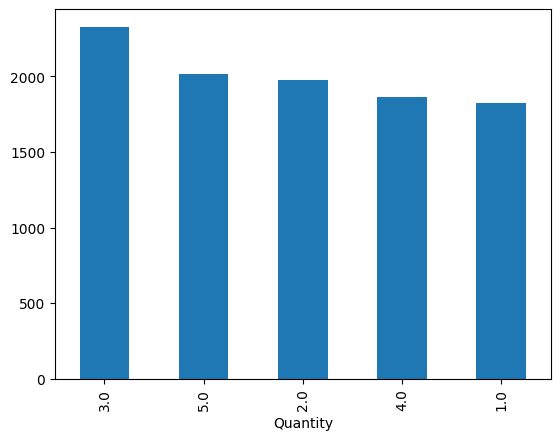

In [56]:
df['Quantity'].value_counts().plot(kind='bar')
plt.show()

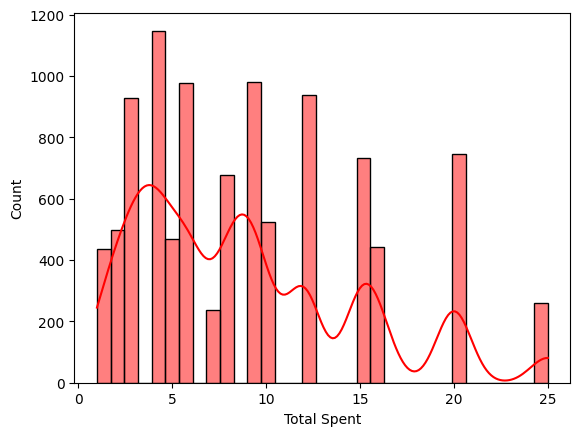

In [57]:
sns.histplot(df['Total Spent'], kde=True,color='Red')
plt.show()

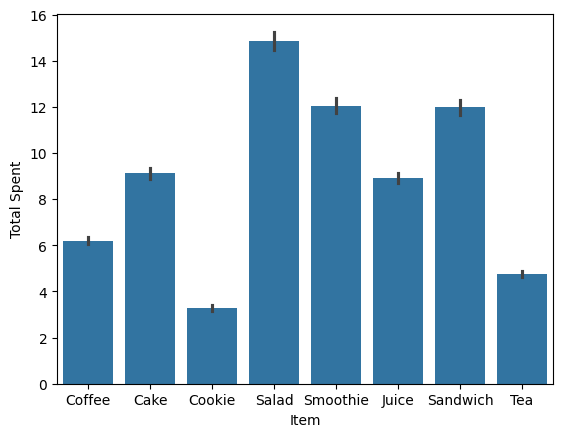

In [58]:
sns.barplot(x=df['Item'],y=df['Total Spent'])
plt.show()

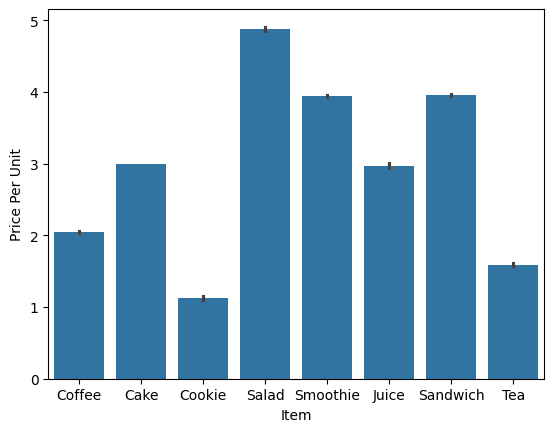

In [59]:
sns.barplot(x=df['Item'],y=df['Price Per Unit'])
plt.show()

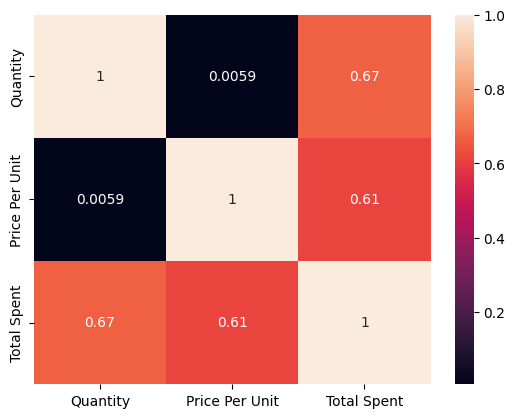

In [60]:
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(data=numerical_df.corr(), annot=True)
plt.show()

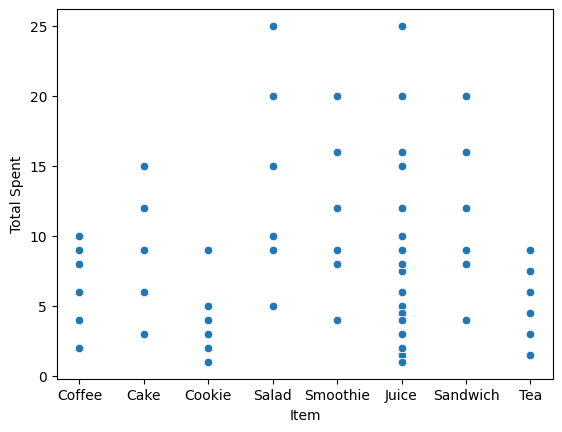

In [61]:
sns.scatterplot(x='Item',y='Total Spent',data=df)
plt.show()

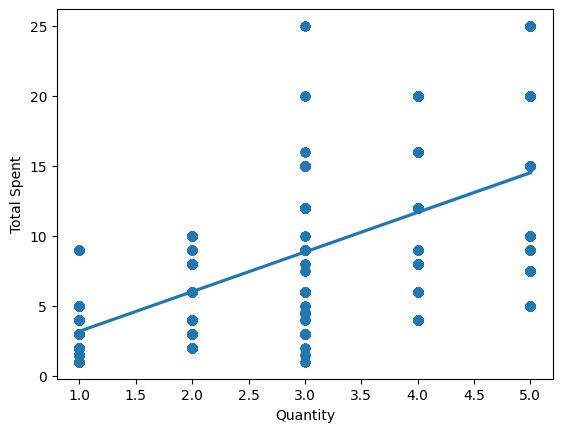

In [62]:
sns.regplot(x='Quantity',y='Total Spent',data=df)
plt.show()

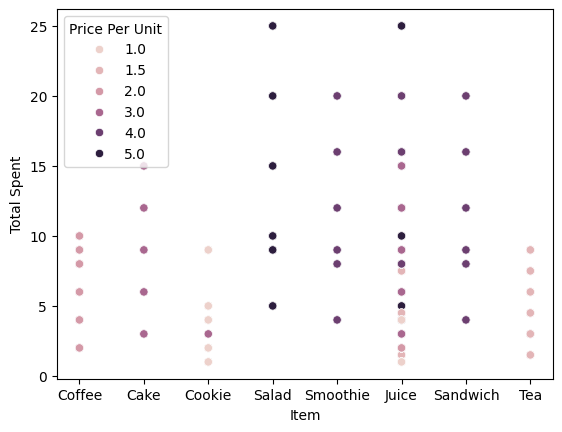

In [63]:
sns.scatterplot(x='Item',y='Total Spent',hue='Price Per Unit',data=df)
plt.show()

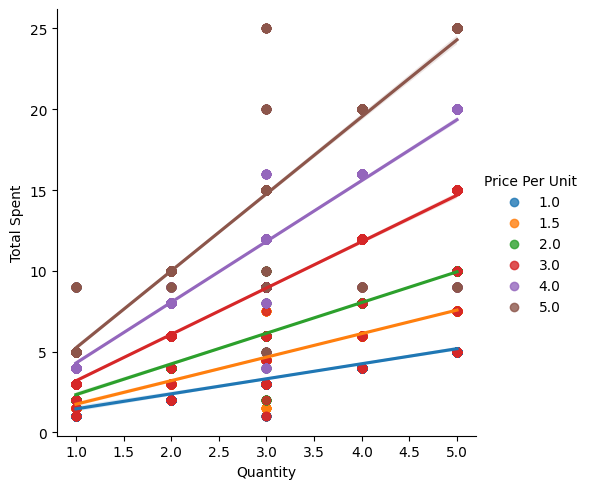

In [64]:
sns.lmplot(x='Quantity',y='Total Spent',hue='Price Per Unit',data=df)
plt.show()

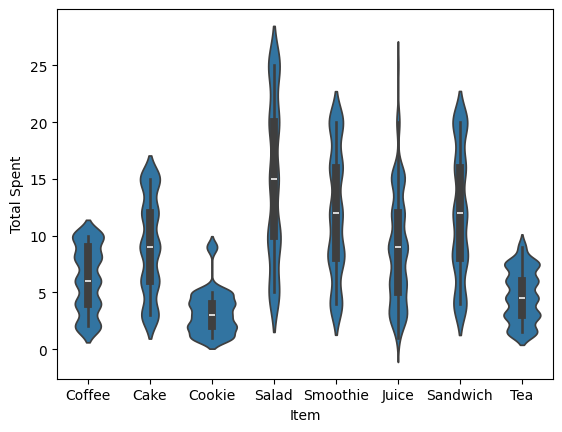

In [65]:
sns.violinplot(x=df['Item'],y=df["Total Spent"])
plt.xlab="Items"
plt.ylab="Total Spent"
plt.title="Violin Plot"
plt.show()

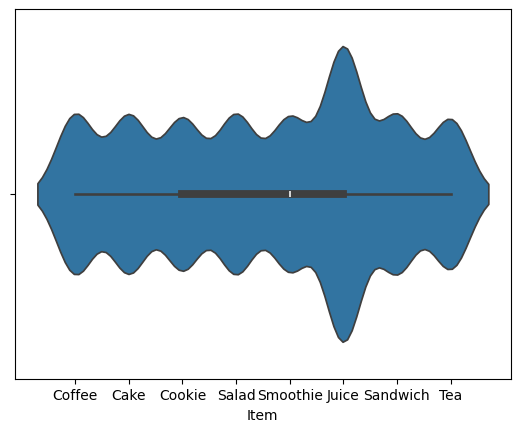

In [66]:
sns.violinplot(x=df['Item'])
plt.show()

<Figure size 800x800 with 0 Axes>

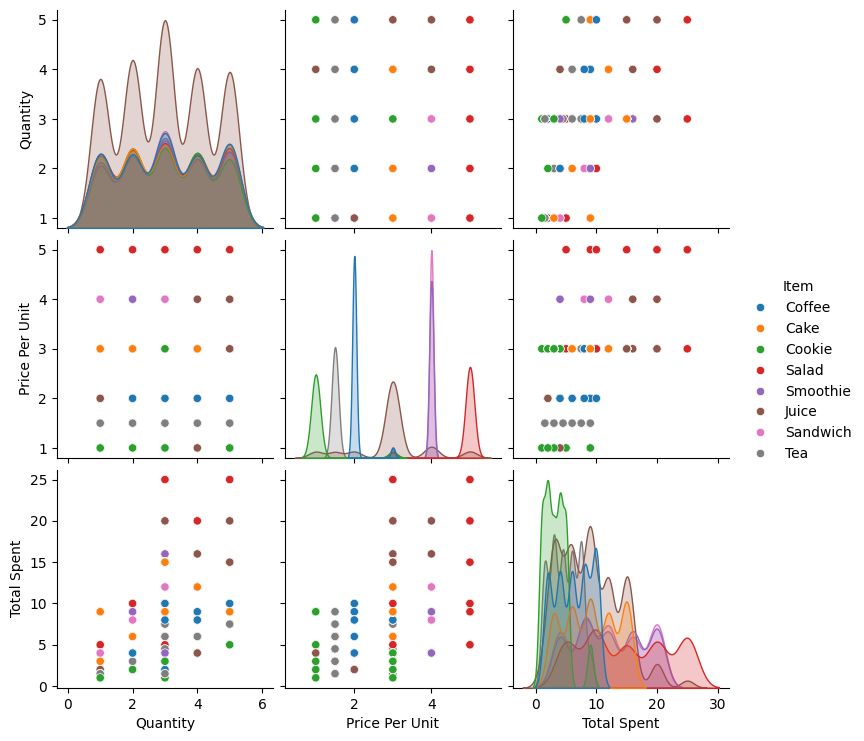

In [67]:
plt.figure(figsize=(8,8))
sns.pairplot(data=df,hue="Item")
plt.show()

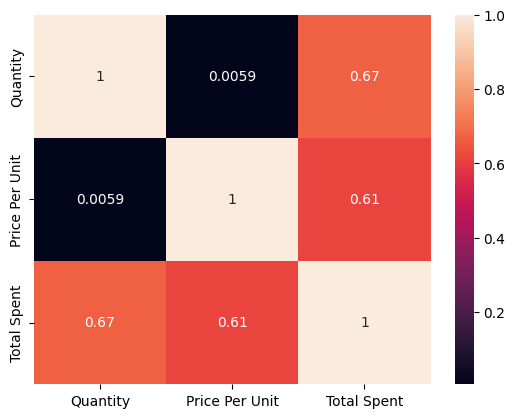

In [68]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

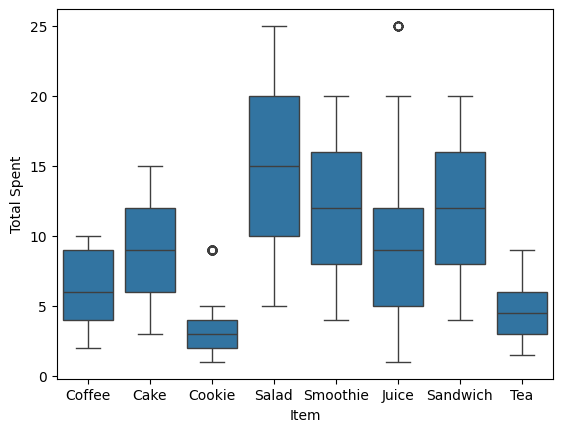

In [69]:
sns.boxplot(x=df['Item'],y=df['Total Spent'])
plt.show()

In [70]:
df["Total Spent"].describe()

,Total Spent
count,10000.000000
mean,8.928150
std,5.857136
min,1.000000
25%,4.000000
50%,8.000000
75%,12.000000
max,25.000000


In [71]:
IQR=12.000000-4.000000
IQR

8.0

In [72]:
max_lim = 12.000000 + 1.5 * IQR
max_lim

24.0

In [73]:
df[df['Total Spent']>max_lim]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
51,TXN_6342161,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-08
52,TXN_8914892,Juice,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-03-15
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10
100,TXN_9517146,Juice,5.0,5.0,25.0,Cash,Takeaway,2023-10-30
...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-01-04
9805,TXN_9506076,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-17
9879,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-10-19
9908,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Takeaway,2023-06-22


In [74]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
Q1,Q3

(np.float64(4.0), np.float64(12.0))

In [75]:
# IQR = Q3 - Q1
# IQR

In [76]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [77]:
outliers = df[(df['Total Spent'] < lower_bound) | (df['Total Spent'] > upper_bound)]

outliers

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
51,TXN_6342161,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-08
52,TXN_8914892,Juice,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-03-15
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10
100,TXN_9517146,Juice,5.0,5.0,25.0,Cash,Takeaway,2023-10-30
...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-01-04
9805,TXN_9506076,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-17
9879,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-10-19
9908,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Takeaway,2023-06-22


In [78]:
outliers.shape

(259, 8)

In [79]:
len(outliers)

259

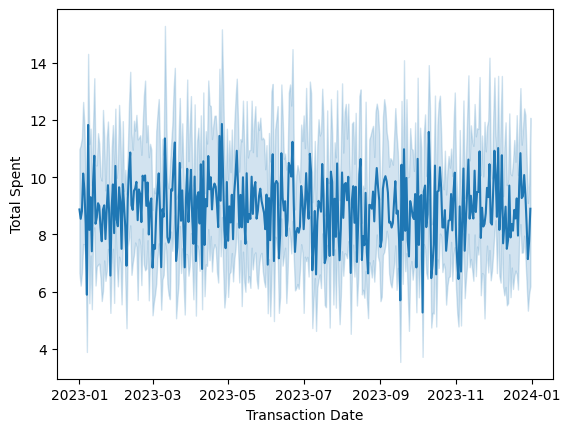

In [80]:
sns.lineplot(x=df['Transaction Date'],y=df['Total Spent'])
plt.show()

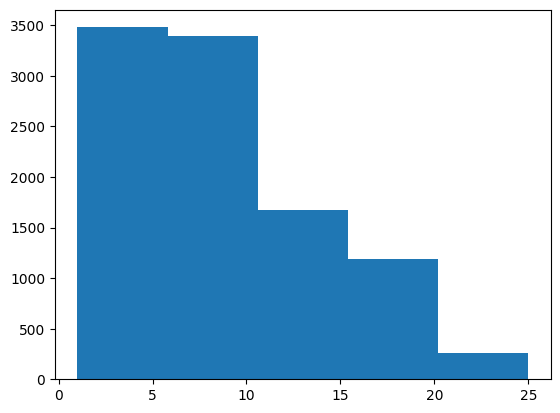

In [81]:
plt.hist(x=df['Total Spent'],bins=5)
plt.show()

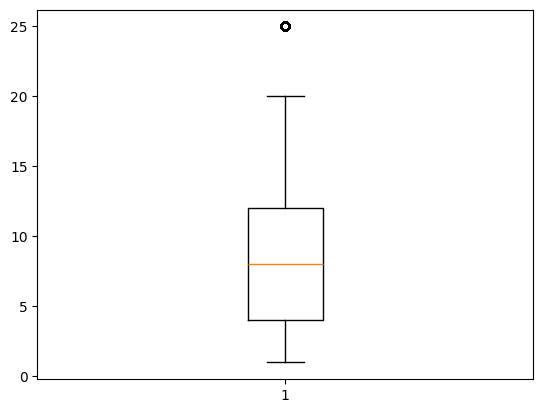

In [82]:
plt.boxplot(df['Total Spent'])
plt.show()

In [83]:
count=df['Item'].value_counts()
count

,count
Item,
Juice,2140
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089


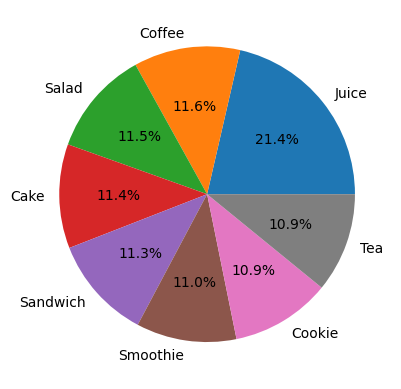

In [84]:
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.show()

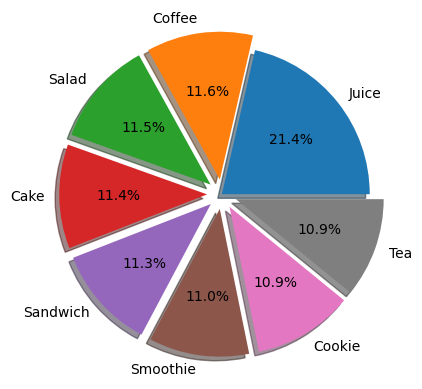

In [85]:
plt.pie(count,labels=count.index,autopct='%1.1f%%',explode=[0,0.1,0.1,0.1,0.1,0.1,0.1,0.1],shadow=True)
plt.show()

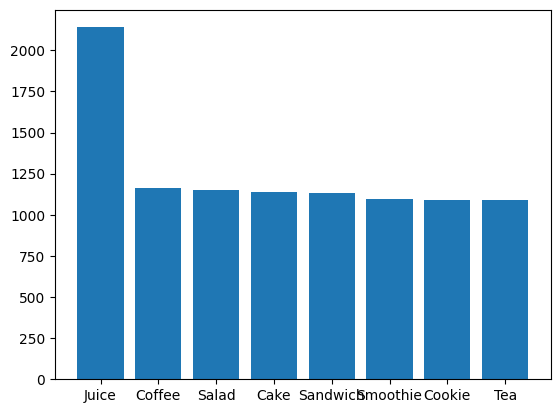

In [86]:
plt.bar(count.index,count)
plt.show()

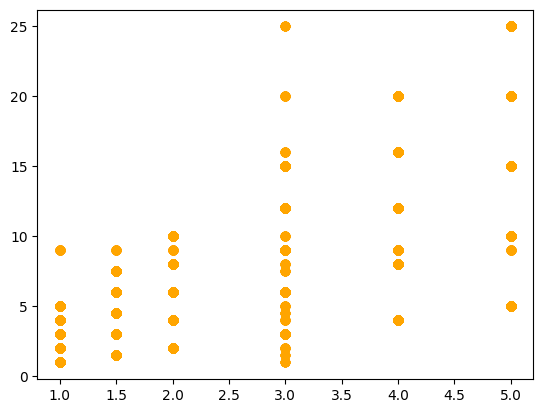

In [87]:
plt.scatter(df['Price Per Unit'],df['Total Spent'],color='orange')
plt.show()


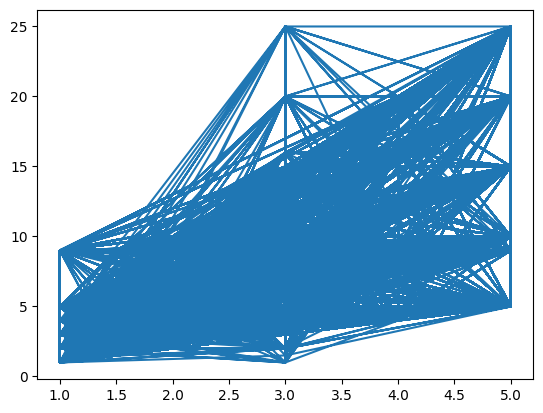

In [88]:
plt.plot(df['Price Per Unit'],df['Total Spent'])
plt.show()


In [89]:
P=df['Price Per Unit'].sort_values()
T=df['Total Spent'].sort_values()
P,T

(33      1.0
 9875    1.0
 55      1.0
 9901    1.0
 9894    1.0
        ... 
 6483    5.0
 10      5.0
 9940    5.0
 9942    5.0
 9973    5.0
 Name: Price Per Unit, Length: 10000, dtype: float64,
 9976     1.0
 9894     1.0
 9901     1.0
 3448     1.0
 3454     1.0
         ... 
 8965    25.0
 4326    25.0
 10      25.0
 6419    25.0
 1947    25.0
 Name: Total Spent, Length: 10000, dtype: float64)

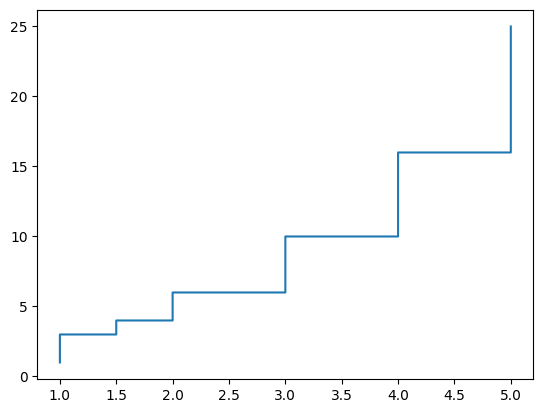

In [90]:
plt.plot(P,T)
plt.show()

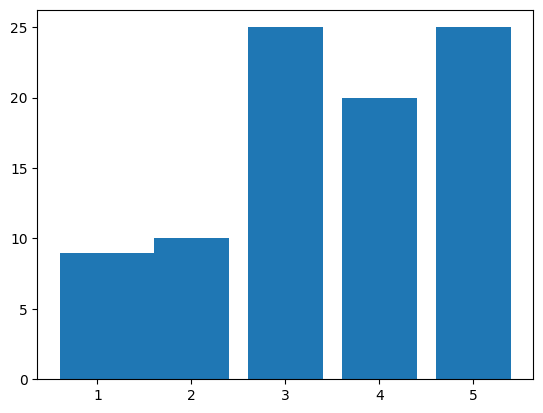

In [91]:
plt.bar(df['Price Per Unit'],df['Total Spent'],align='center')
plt.show()

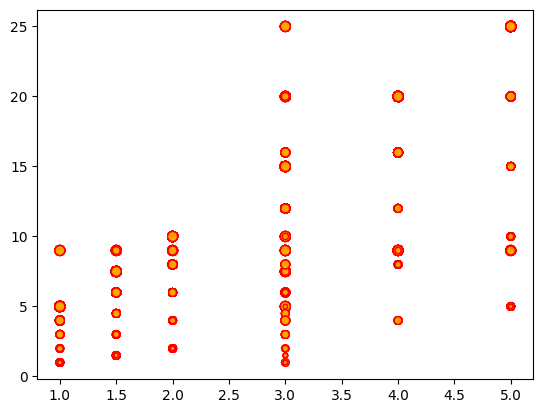

In [92]:
plt.scatter(df['Price Per Unit'],df['Total Spent'],s=df["Quantity"]*10,color='orange',edgecolors="red")
plt.show()

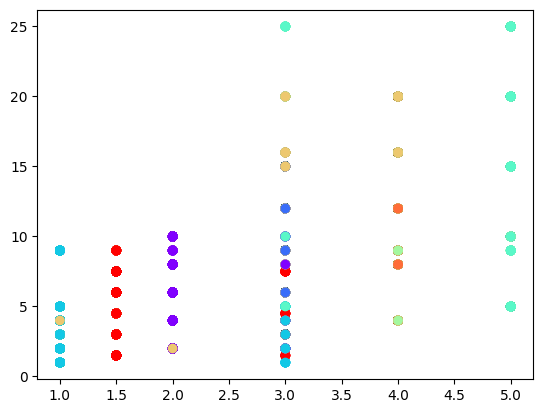

In [93]:
plt.scatter(df['Price Per Unit'],df['Total Spent'],c=pd.factorize(df['Item'])[0],cmap="rainbow")
plt.show()